<a href="https://colab.research.google.com/github/bw123111/csci547_ML/blob/main/assignments/kaggle_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle competition #2


You've learned a great deal about supervised learning and now it's time to bring together all that you've learned. You will be competing in a 'Kaggle Competition' along with the rest of the class! Your goal is to predict the 'target' based on the features provided.  While you will be asked to take certain steps along the way to your submission, you're encouraged to try creative solutions to this problem and your choices are wide open for you to make your decisions on how to best make the predictions.

The competition is hosted [here](https://www.kaggle.com/competitions/umt-csci-447-547-fall-2025-competition). Please follow the directions on kaggle to submit your predictions.


**The Data**. This is a regression problem with 20 numerical predictors and 1 target. You have access to 400 training samples, and there are 800 testing samples. You will train your model on the training samples and then make predictions on the 800 testing samples, which you will submit (as a .csv file) to be scored. There is an example testing submission file included to demonstrate how the submission files should look.

**Scoring**. Your performance will be judged using mean-squared error (MSE).  You will submit your predictions to kaggle using the submission instructions. The leaderboard will show your performance on half of the testing samples (400 samples), while another 400 remain for "private" testing, and your score on this private set will be revealed at the end of the competition. You will need to achieve a minimum acceptable level of performance to demonstrate proficiency with using these supervised learning techniques.  

Beyond that, it's an open competition and scoring in the top three places of the private leaderboard will result in \textbf{5 bonus points in this assignment} (and the pride of the class!). Note: the Kaggle leaderboard has a public and private component. The public component is viewable throughout the competition, but the private leaderboard is revealed at the end. When you make a submission, you immediately see your submission on the public leaderboard, but that only represents scoring on a fraction of the total collection of test data, the rest remains hidden until the end of the competition to prevent overfitting to the test data through repeated submissions. You will be be allowed to hand-select two eligible submissions for private score, or by default your best two public scoring submissions will be selected for private scoring.

**Grade** Your grade on this will be based on both your performance (50 points) and the notebook you submit (40 points).  As always, an additional 10 points are allocated to presentation quality. For your notebook, your grade will depend on the following:

### Guidance:
1. **Preprocessing**. You may need to preprocess the data for some of these models to perform well (scaling inputs or reducing dimensionality). Some of this preprocessing may differ from model to model to achieve the best performance. A helpful tool for creating such preprocessing and model fitting pipelines is the sklearn `pipeline` module which lets you group a series of processing steps together.
2. **Hyperparameters**. Hyperparameters may need to be tuned for some of the models you use. You may want to perform hyperparameter tuning for some of the models. `optuna` is a great framework for this, if you want to try it out. If you experiment with different hyperparameters that include many model runs, you may want to apply them to a small subsample of your overall data before running it on the larger training set to be time efficient (if you do, just make sure to ensure your selected subset is representative of the rest of your data).
3. **Validation data**. You're encouraged to create your own validation dataset for comparing model performance; without this, there's a significant likelihood of overfitting to the data. A common choice of the split is 80% training, 20% validation. Before you make your final predictions on the test data, be sure to retrain your model on the entire dataset.


**Data Import and Exploration**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train = pd.read_csv('https://raw.githubusercontent.com/bw123111/csci547_ML/refs/heads/main/assignments/data/Kaggle_competition2/train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/bw123111/csci547_ML/refs/heads/main/assignments/data/Kaggle_competition2/test.csv')

print(f"Train shape: {train.shape} \nTest shape: {test.shape}")
train.head()

Train shape: (400, 22) 
Test shape: (800, 21)


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,target
0,1,0.813120,-0.317922,0.027886,2.966993,1.792626,1.639461,1.038417,-1.265553,2.737895,...,2.074784,-0.549459,0.588724,0.670610,0.102525,1.963463,-0.349565,-0.294764,-0.206112,-18.759727
1,2,1.187370,0.574752,0.480094,1.003127,1.743455,1.653923,0.289389,1.758154,1.447072,...,0.904899,0.936627,0.692230,0.631463,1.022266,2.211432,-0.318560,0.696366,0.693999,8.082223
2,3,0.713207,-0.061996,0.423746,0.111901,1.763365,1.651579,1.026891,1.283781,1.116797,...,1.581493,1.151487,0.213017,0.766878,1.003003,1.824628,1.248738,NaN,0.600792,2.961315
3,4,0.779316,0.687488,0.388627,1.343889,1.743500,1.641686,-0.670589,0.135970,1.553194,...,1.995739,0.650913,0.925546,0.657044,0.558577,1.915205,2.763816,1.665433,0.397841,-0.710178
4,5,0.674119,-0.286842,0.386524,2.416830,1.787492,1.636464,1.782221,0.722959,2.030776,...,0.485689,-1.000375,0.970572,0.900548,0.638401,1.893995,-2.186096,1.838846,1.070571,5.328069


In [15]:
train.describe()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,target
count,400.000000,395.000000,398.000000,397.000000,397.000000,393.000000,398.000000,396.000000,397.000000,397.000000,...,397.000000,394.000000,395.000000,400.000000,395.000000,396.000000,398.000000,397.000000,394.000000,400.000000
mean,200.500000,0.929817,0.103775,0.399106,0.624035,1.733973,1.658296,0.674185,1.528509,1.506796,...,1.215997,0.416822,0.575530,0.747083,0.798745,1.994602,0.557108,1.206750,0.469494,-1.130048
std,115.614301,0.230155,0.443145,0.181493,1.356035,0.050163,0.052309,0.938464,1.343001,0.655062,...,0.984864,1.095934,0.212071,0.192322,0.363336,1.215101,1.415854,0.777583,0.494618,10.848223
min,1.000000,0.283227,-1.197332,-0.198983,-3.298943,1.601365,1.506374,-2.125939,-2.467309,-0.361726,...,-1.858385,-2.443500,-0.099370,0.115061,-0.164741,-1.437118,-4.529443,-1.292303,-0.873796,-56.422845
25%,100.750000,0.789294,-0.198059,0.267863,-0.305175,1.702095,1.623567,0.054529,0.593326,1.064722,...,0.599725,-0.326329,0.418883,0.619042,0.531878,1.223741,-0.406788,0.692043,0.097671,-5.335921
50%,200.500000,0.946842,0.096516,0.411260,0.506337,1.732611,1.656562,0.643489,1.595760,1.486259,...,1.258694,0.439387,0.578007,0.747589,0.786984,2.009483,0.532240,1.220152,0.458768,-0.510613
75%,300.250000,1.082765,0.413801,0.522271,1.515553,1.765177,1.694608,1.274544,2.495724,1.985032,...,1.903233,1.095831,0.726754,0.880957,1.059191,2.828374,1.502131,1.759239,0.818868,3.934202
max,400.000000,1.588043,1.212879,0.884020,4.304862,1.889694,1.816105,3.260017,5.205119,3.271230,...,3.933328,3.741093,1.069151,1.335387,1.884126,5.748790,4.764340,3.165238,1.743199,36.101080


**Test data summary**

In [5]:
test.head()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
0,401,0.969811,-0.389490,-0.075381,-1.505691,1.720168,1.735027,1.356886,-1.708672,0.604604,...,2.967954,0.746284,1.301299,0.550946,0.690254,0.223682,1.851455,0.318604,0.762520,0.472288
1,402,1.121796,0.768937,0.362358,-1.123408,1.773125,1.708505,-0.983776,1.381184,0.678767,...,-2.444318,1.238919,0.061478,0.641270,0.961008,0.633535,2.458810,0.983950,2.324804,0.686668
2,403,1.085732,0.207999,0.285440,NaN,1.607725,1.595718,0.561353,0.854037,1.641407,...,2.914548,3.810751,0.350238,0.568409,0.780886,0.792704,1.701120,-2.529507,1.029163,0.591332
3,404,1.079724,0.303261,0.397446,-0.757769,1.723312,1.702758,0.075594,0.862485,1.113665,...,2.071923,2.244971,-0.495614,0.611114,0.795765,1.642672,2.099708,1.441551,1.460350,0.047208
4,405,0.733227,-0.122467,0.517686,1.088353,1.878982,1.655497,1.579678,2.204686,1.893622,...,0.975109,2.274006,-1.562658,0.840123,0.663351,1.527473,2.678541,1.296108,1.211495,0.542183


In [16]:
test.describe()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
count,800.0000,792.000000,793.000000,790.000000,794.000000,796.000000,795.000000,796.000000,788.000000,787.000000,...,793.000000,792.000000,795.000000,790.000000,791.000000,793.000000,792.000000,789.000000,788.000000,789.000000
mean,800.5000,0.922187,0.089932,0.393375,0.741476,1.737368,1.658658,0.695658,1.454017,1.563485,...,0.482627,1.228638,0.421218,0.566846,0.741701,0.784357,1.999208,0.617907,1.223967,0.490811
std,231.0844,0.247038,0.416870,0.181306,1.380126,0.048176,0.056257,0.875495,1.272151,0.649062,...,2.170702,1.019518,1.072719,0.207715,0.207896,0.345019,1.166512,1.369179,0.784717,0.477336
min,401.0000,0.179166,-1.211708,-0.123744,-3.346579,1.593022,1.497201,-2.276049,-2.570132,-0.256511,...,-5.366991,-2.071085,-2.838001,-0.087603,-0.037398,-0.307456,-2.066978,-3.462699,-1.030878,-1.024568
25%,600.7500,0.770882,-0.196616,0.279383,-0.152365,1.705727,1.620881,0.119836,0.666473,1.124636,...,-1.061285,0.555759,-0.307616,0.427330,0.601736,0.566556,1.218908,-0.327380,0.725737,0.190116
50%,800.5000,0.922555,0.101894,0.389584,0.763542,1.737265,1.657115,0.694288,1.428990,1.593320,...,0.485389,1.271342,0.461226,0.566073,0.749983,0.792893,2.000624,0.636303,1.215858,0.489500
75%,1000.2500,1.079115,0.344277,0.502395,1.654228,1.770761,1.695984,1.302362,2.331040,2.006495,...,2.066701,1.906454,1.125098,0.705727,0.881620,1.001793,2.785157,1.491039,1.736114,0.809978
max,1200.0000,1.730196,1.484091,0.921580,5.067383,1.878982,1.819626,3.498136,5.184836,3.840651,...,6.299607,4.983798,4.048099,1.140148,1.393733,1.755410,5.327498,4.873214,3.825004,2.040363


**Boxplots of data covariates**

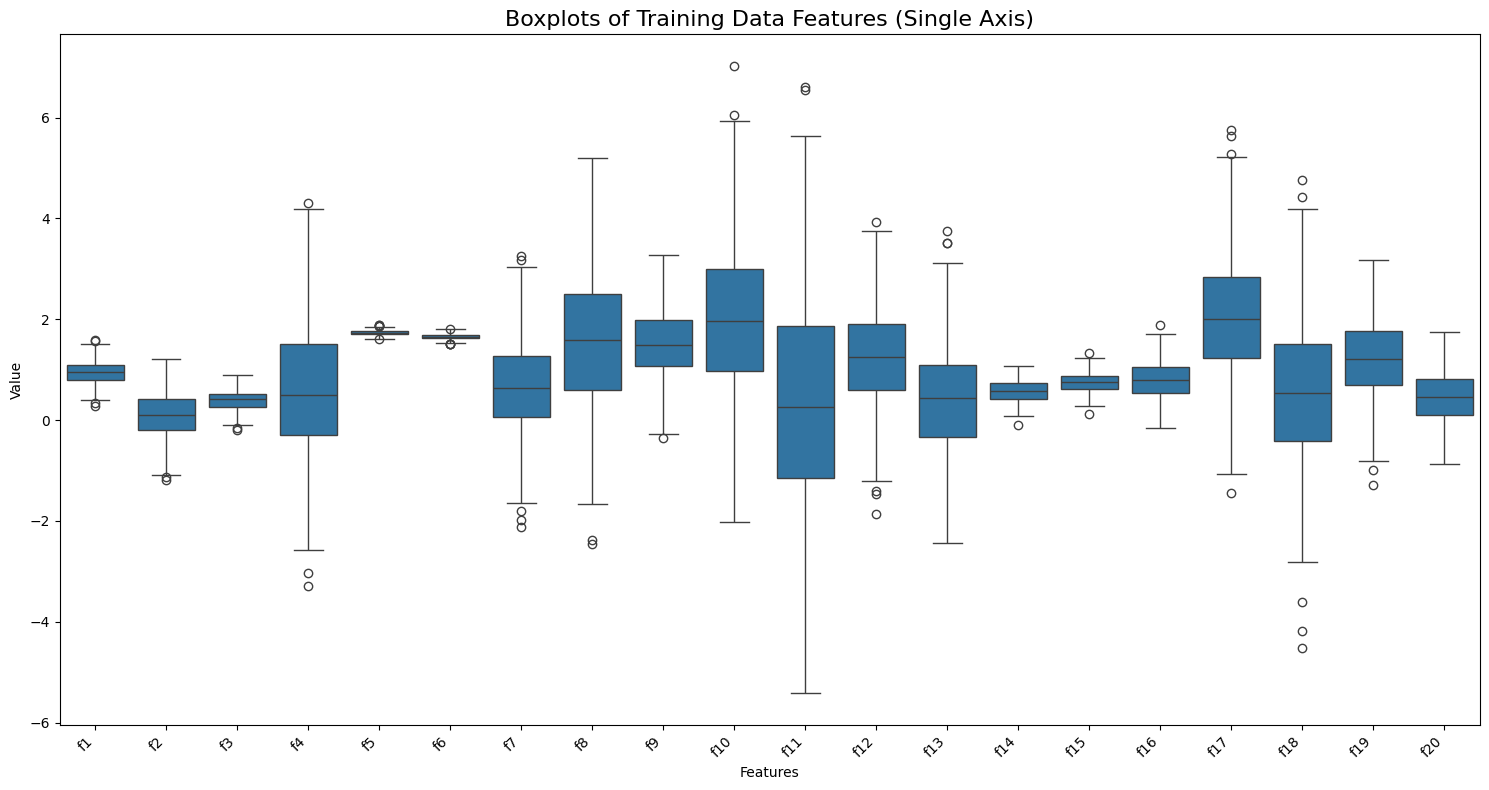

In [18]:
features = train.drop(columns=['id', 'target']).columns

# Melt the DataFrame to long format for plotting of each covariate boxplots on same axes
train_melted = train[features].melt(var_name='feature', value_name='value')

plt.figure(figsize=(15, 8)) # Adjust figure size as needed
sns.boxplot(x='feature', y='value', data=train_melted)
plt.title('Boxplots of Training Data Features (Single Axis)', fontsize=16)
plt.xlabel('Features')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Preprocess data**  
e.g. normalization, NA handling, traintestsplit training data/separate out a validation dataset.   
comments: what was done, WHY for each step


**Train 5+ models**  
some options:

Linear regression  
Polynomial regression  
Lasso regression  
Ridge regression  
Decision tree regression  
Random forest regression  
Support vector regression  

Some of these can be experiments with different hyperparameter-tuned versions of the same model


**Evaluate models**

Assess the regression performance AND computational efficiency of the models you selected:

- Visualize the model fit to the training data. Using the models you created in part (c), plot the original data (as a scatter plot) AND the curves representing your models (each as a separate curve) from (c). One of these models should also be your BEST performing submission (based on evalutation using your test dataset). Label it as such.
- As you train and validate each model, time how long it takes to train and validate in each case and create a plot that shows both the training and prediction time for each model included.
- Describe:
  - Your process of model selection and hyperparameter tuning
  - Which model performed best and your process for identifying/selecting it

**(d) Apply your model "in practice".**  
Compare at least 5 different model results (using the test data provided). These do not need to be the same that you report on above, but you should select your *most competitive* models.
- Be sure to RETRAIN YOUR MODEL ON ALL LABELED TRAINING AND VALIDATION DATA before making your predictions on the test data for submission. This will help to maximize your performance on the test data.